In [87]:
import pandas as pd
import numpy as np
import re

In [88]:
# Load the dataset
raw_path = "flights_data.csv"
df = pd.read_csv(raw_path)

In [89]:
df.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops,Unnamed: 11,Unnamed: 12
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55,Mumbai,21:05,02h 10m,"6,013",non-stop,NaN,NaN
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20,Mumbai,08:40,02h 20m,"6,013",non-stop,NaN,NaN
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25,Mumbai,06:35,02h 10m,"6,016",non-stop,NaN,NaN
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20,Mumbai,12:35,02h 15m,"6,015",non-stop,NaN,NaN
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50,Mumbai,11:10,02h 20m,"6,015",non-stop,NaN,NaN


In [90]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
df = df.drop(columns=empty_cols)

In [91]:
# Convert to lowercase, remove leading/trailing spaces, replace spaces with underscores.
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print("\nStandardised columns:", df.columns.tolist())



Standardised columns: ['flight_date', 'airline', 'flight_num', 'class', 'from', 'dep_time', 'to', 'arr_time', 'duration', 'price', 'stops']


In [92]:
# 4) Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"\nRemoved duplicates: {before - after}")
print("Shape after duplicates removal:", df.shape)


Removed duplicates: 2
Shape after duplicates removal: (300259, 11)


In [93]:
# 5) Trim whitespace in text columns
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

print("\nTrimmed whitespace in object columns.")


Trimmed whitespace in object columns.


In [94]:
# 6) Convert flight_date to datetime
# Your dataset uses format like "26-06-2023" (day-first).
df["flight_date"] = pd.to_datetime(df["flight_date"], dayfirst=True, errors="coerce")

# Drop rows where flight_date could not be parsed
df = df[df["flight_date"].notna()].reset_index(drop=True)

print("\nflight_date parsed. Missing flight_date rows removed.")
print("Shape:", df.shape)


flight_date parsed. Missing flight_date rows removed.
Shape: (300259, 11)


In [95]:
# 7) Convert time columns to minutes since midnight
# This makes time usable for ML models.
def time_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    m = re.match(r"^(\d{1,2}):(\d{2})$", x)
    if not m:
        return np.nan
    hh, mm = int(m.group(1)), int(m.group(2))
    if hh < 0 or hh > 23 or mm < 0 or mm > 59:
        return np.nan
    return hh * 60 + mm

df["dep_minutes"] = df["dep_time"].apply(time_to_minutes)
df["arr_minutes"] = df["arr_time"].apply(time_to_minutes)

In [96]:
print("Shape:", df.shape)


Shape: (300259, 13)


In [97]:
# 8) Clean price (remove commas) and convert to numeric
# Example: "6,013" -> 6013
df["price"] = (
    df["price"].astype(str)
      .str.replace(",", "", regex=False)
      .str.strip()
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [98]:
# Remove invalid prices (missing or <= 0)
df = df[df["price"].notna() & (df["price"] > 0)].reset_index(drop=True)

print("\nCleaned price column and removed invalid prices.")
print("Shape:", df.shape)
print(df["price"].describe())


Cleaned price column and removed invalid prices.
Shape: (300259, 13)
count    300259.000000
mean      21174.447460
std       23048.549457
min        1116.000000
25%        4831.000000
50%        7499.000000
75%       43159.000000
max      124917.000000
Name: price, dtype: float64


In [99]:
#Convert duration to minutes

# Format: "02h 10m" -> 130 minutes
def duration_to_minutes(x):
    """Convert duration string like '02h 10m' to total minutes."""
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(" ", "")
    h = re.search(r"(\d+)h", s)
    m = re.search(r"(\d+)m", s)
    hours = int(h.group(1)) if h else 0
    mins = int(m.group(1)) if m else 0
    total = hours * 60 + mins
    return total if total > 0 else np.nan

df["duration_mins"] = df["duration"].apply(duration_to_minutes)



In [100]:
# Remove invalid duration rows
df = df[df["duration_mins"].notna()].reset_index(drop=True)

print("\nConverted duration to minutes and removed invalid durations.")
print("Shape:", df.shape)



Converted duration to minutes and removed invalid durations.
Shape: (300259, 14)


In [101]:
# Clean stops column -> stops_count + via_city
# stops examples include:
# "non-stop", "1-stop ... Via IXU", "2+-stop"
def extract_via_city(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"via\s+([A-Za-z]+)", str(x), flags=re.IGNORECASE)
    return m.group(1).strip().title() if m else np.nan

def extract_stops_count(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    if "non-stop" in s:
        return 0
    if s.startswith("1-stop"):
        return 1
    if s.startswith("2+-stop") or s.startswith("2+stop"):
        return 2
    # fallback patterns like "2-stop"
    m = re.match(r"^(\d+)\s*-\s*stop", s)
    if m:
        return int(m.group(1))
    return np.nan

df["via_city"] = df["stops"].apply(extract_via_city)
df["stops_count"] = df["stops"].apply(extract_stops_count)

# Remove rows where stops_count is missing (or you can impute)
df = df[df["stops_count"].notna()].reset_index(drop=True)

print("\nExtracted stops_count and via_city. Removed rows with invalid stops.")
print(df["stops_count"].value_counts())
print("Shape:", df.shape)


Extracted stops_count and via_city. Removed rows with invalid stops.
stops_count
1    250927
0     36044
2     13288
Name: count, dtype: int64
Shape: (300259, 16)


In [102]:
# 11) Create date features (useful for EDA & ML)
df["flight_day"] = df["flight_date"].dt.day
df["flight_month"] = df["flight_date"].dt.month
df["flight_weekday"] = df["flight_date"].dt.dayofweek  # Monday=0

print("\nCreated date-based features: day, month, weekday.")



Created date-based features: day, month, weekday.


In [103]:

# Your dataset includes columns like from/to which we'll rename for clarity.
if "from" in df.columns:
    df = df.rename(columns={"from": "source_city"})
if "to" in df.columns:
    df = df.rename(columns={"to": "destination_city"})

# Standardise text formatting
for col in ["airline", "source_city", "destination_city"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

if "class" in df.columns:
    df["class"] = df["class"].astype(str).str.strip().str.lower()

print("\nStandardised categorical columns (title/lower case).")


Standardised categorical columns (title/lower case).


In [104]:

# 13) Select final cleaned columns (keep only what you need)
final_cols = [
    "flight_date", "flight_num", "airline", "class",
    "source_city", "destination_city",
    "dep_time", "arr_time", "dep_minutes", "arr_minutes",
    "duration", "duration_mins",
    "stops", "stops_count", "via_city",
    "price",
    "flight_day", "flight_month", "flight_weekday"
]

# Keep only columns that exist (safe for slight dataset variations)
final_cols = [c for c in final_cols if c in df.columns]
df_clean = df[final_cols].copy()
df_clean.head()

,flight_date,flight_num,airline,class,source_city,destination_city,dep_time,arr_time,dep_minutes,arr_minutes,duration,duration_mins,stops,stops_count,via_city,price,flight_day,flight_month,flight_weekday
0,2023-06-26,SG-8709,Spicejet,economy,Delhi,Mumbai,18:55,21:05,1135,1265,02h 10m,130,non-stop,0,NaN,6013,26,6,0
1,2023-06-26,SG-8157,Spicejet,economy,Delhi,Mumbai,06:20,08:40,380,520,02h 20m,140,non-stop,0,NaN,6013,26,6,0
2,2023-06-26,I5-764,Airasia,economy,Delhi,Mumbai,04:25,06:35,265,395,02h 10m,130,non-stop,0,NaN,6016,26,6,0
3,2023-06-26,UK-995,Vistara,economy,Delhi,Mumbai,10:20,12:35,620,755,02h 15m,135,non-stop,0,NaN,6015,26,6,0
4,2023-06-26,UK-963,Vistara,economy,Delhi,Mumbai,08:50,11:10,530,670,02h 20m,140,non-stop,0,NaN,6015,26,6,0


In [105]:
#Save cleaned dataset
out_path = "flights_cleaned.csv"
df_clean.to_csv(out_path, index=False)

print("\nSaved cleaned dataset to:", out_path)


Saved cleaned dataset to: flights_cleaned.csv


/tmp/ipykernel_5357/1978204004.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flights_cleaned.csv")


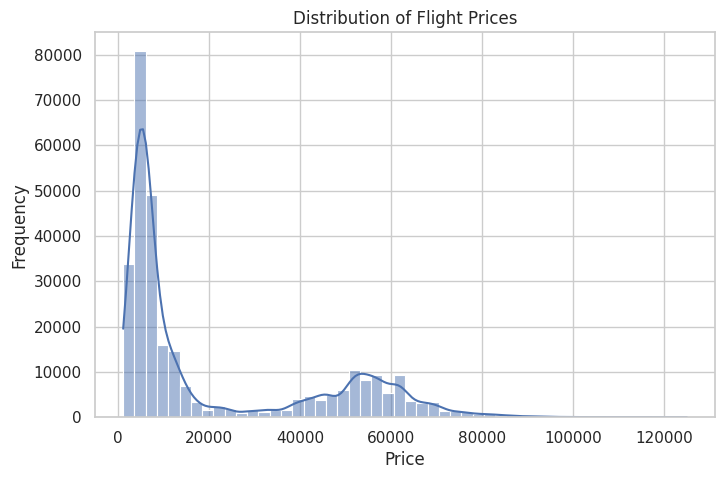

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("flights_cleaned.csv")

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

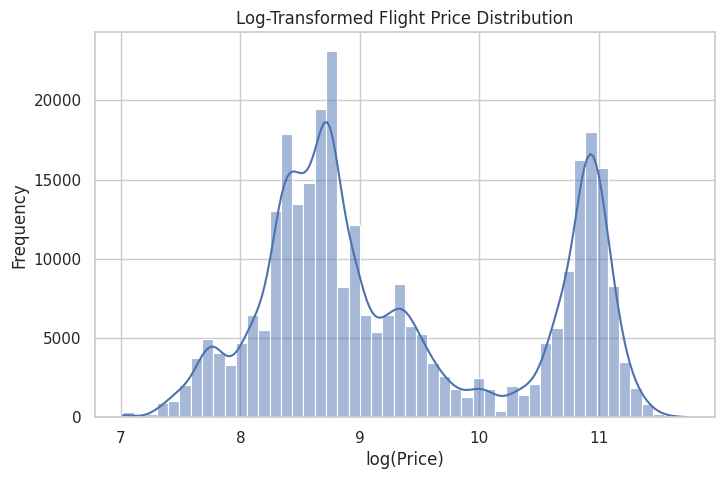

In [107]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("Log-Transformed Flight Price Distribution")
plt.xlabel("log(Price)")
plt.ylabel("Frequency")
plt.show()


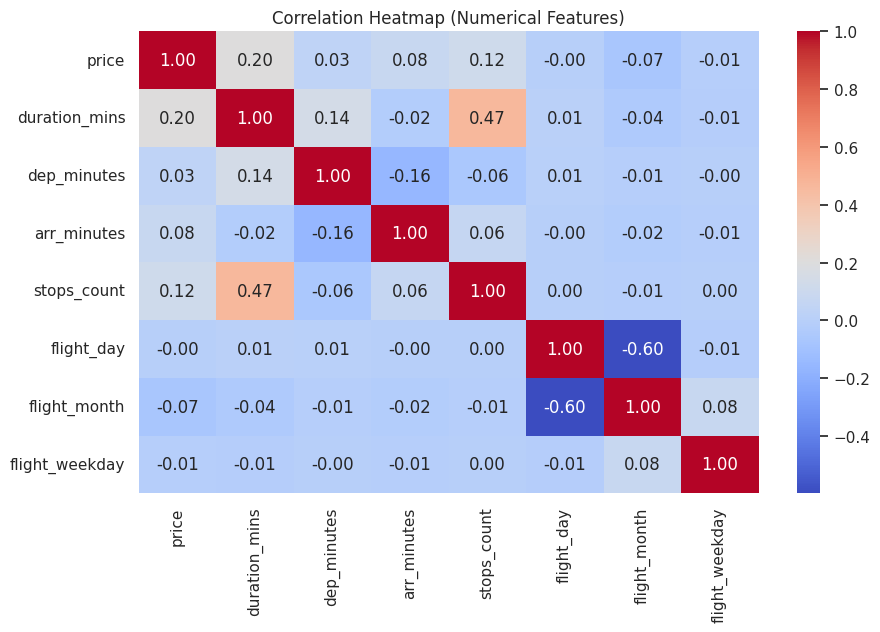

In [108]:
num_cols = [
    "price", "duration_mins",
    "dep_minutes", "arr_minutes",
    "stops_count", "flight_day",
    "flight_month", "flight_weekday"
]

plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


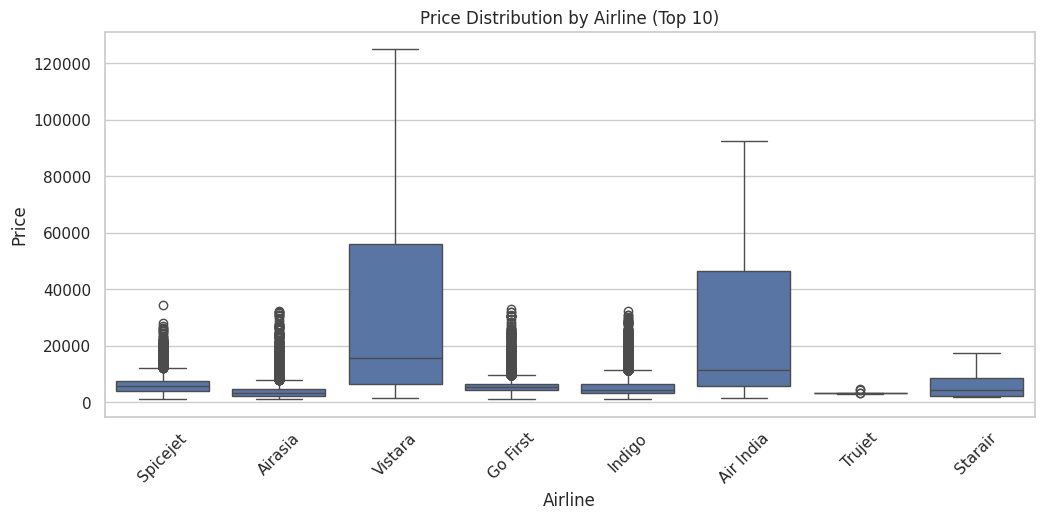

In [109]:
top_airlines = df["airline"].value_counts().head(10).index

plt.figure(figsize=(12,5))
sns.boxplot(
    x="airline",
    y="price",
    data=df[df["airline"].isin(top_airlines)]
)
plt.xticks(rotation=45)
plt.title("Price Distribution by Airline (Top 10)")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()


In [110]:
import pandas as pd
import numpy as np

df = pd.read_csv("goibibo_flights_cleaned.csv", dtype={'via_city': str})

In [111]:
# Create log target
df["log_price"] = np.log1p(df["price"])

# Use only safe columns
model_cols = [
    "airline",
    "class",
    "source_city",
    "destination_city",
    "dep_minutes",
    "arr_minutes",
    "duration_mins",
    "stops_count",
    "flight_day",
    "flight_month",
    "flight_weekday",
    "price",
    "log_price"
]

df_model = df[model_cols].copy()

# Drop missing rows
df_model = df_model.dropna().reset_index(drop=True)

print(df_model.shape)
df_model.head()

(300259, 13)


,airline,class,source_city,destination_city,dep_minutes,arr_minutes,duration_mins,stops_count,flight_day,flight_month,flight_weekday,price,log_price
0,Spicejet,economy,Delhi,Mumbai,1135,1265,130,0,26,6,0,6013,8.701845
1,Spicejet,economy,Delhi,Mumbai,380,520,140,0,26,6,0,6013,8.701845
2,Airasia,economy,Delhi,Mumbai,265,395,130,0,26,6,0,6016,8.702344
3,Vistara,economy,Delhi,Mumbai,620,755,135,0,26,6,0,6015,8.702178
4,Vistara,economy,Delhi,Mumbai,530,670,140,0,26,6,0,6015,8.702178


In [112]:
# Start with a safer sample size
sample_size = min(80000, len(df_model))
df_model = df_model.sample(n=sample_size, random_state=42).reset_index(drop=True)

print("Sample shape:", df_model.shape)

Sample shape: (80000, 13)


In [113]:
# IMPORTANT: remove BOTH price and log_price from X
X = df_model.drop(columns=["price", "log_price"])
y = df_model["log_price"]

print("X columns:", X.columns.tolist())
print("Does X contain price?", "price" in X.columns)
print("Does X contain log_price?", "log_price" in X.columns)

X columns: ['airline', 'class', 'source_city', 'destination_city', 'dep_minutes', 'arr_minutes', 'duration_mins', 'stops_count', 'flight_day', 'flight_month', 'flight_weekday']
Does X contain price? False
Does X contain log_price? False


In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(64000, 11) (16000, 11)


In [115]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['airline', 'class', 'source_city', 'destination_city']
Numerical: ['dep_minutes', 'arr_minutes', 'duration_mins', 'stops_count', 'flight_day', 'flight_month', 'flight_weekday']


In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
trained_models = {}

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)

    # Convert back to original price scale
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append({
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

    trained_models[model_name] = {
        "pipeline": pipe,
        "predictions": y_pred
    }

    print(f"\n{model_name}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))

    return pipe

# Linear Regression

In [118]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
evaluate_model("Linear Regression", lr_model, X_train, y_train, X_test, y_test)


Linear Regression
MAE : 4691.97
RMSE: 8088.46
R2  : 0.8766


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['dep_minutes', 'arr_minutes',
                                                   'duration_mins',
                                                   'stops_count', 'flight_day',
                                                   'flight_month',
                                                   'flight_weekday']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['airline', 'class',
                                                   'source_city',
                                                   'destination_city'])])),
                ('model', LinearRegression())])

# Decision Tree Regression

In [119]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

evaluate_model("Decision Tree Regressor", dt_model, X_train, y_train, X_test, y_test)


Decision Tree Regressor
MAE : 2600.47
RMSE: 4796.76
R2  : 0.9566


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['dep_minutes', 'arr_minutes',
                                                   'duration_mins',
                                                   'stops_count', 'flight_day',
                                                   'flight_month',
                                                   'flight_weekday']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['airline', 'class',
                                                   'source_city',
                                                   'destination_city'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=10,
                                       min_samples_split=20,
                                       random_state=42))])

# Random Forest

In [120]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)

evaluate_model("Random Forest Regressor", rf_model, X_train, y_train, X_test, y_test)


Random Forest Regressor
MAE : 1803.49
RMSE: 3511.1
R2  : 0.9767


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['dep_minutes', 'arr_minutes',
                                                   'duration_mins',
                                                   'stops_count', 'flight_day',
                                                   'flight_month',
                                                   'flight_weekday']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['airline', 'class',
                                                   'source_city',
                                                   'destination_city'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=4,
                                       min_samples_split=10, n_jobs=-1,
                                       random_state=42))])

# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

evaluate_model("Gradient Boosting Regressor", gbr_model, X_train, y_train, X_test, y_test)

# ALL model results

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
results_df

# Best performance Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

best_pred = trained_models[best_model_name]["predictions"]
y_true = np.expm1(y_test)

# MAE,RMSE comparision of all models

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by RMSE for better readability
plot_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

models = plot_df["Model"]
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, plot_df["MAE"], width=width, label="MAE")
plt.bar(x,         plot_df["RMSE"], width=width, label="RMSE")

plt.xticks(x, models, rotation=35, ha="right")
plt.ylabel("Metric Value")
plt.title("Comparison of All Regression Models Across MAE AND RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# Variance Comaprison All Models

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(plot_df["Model"], plot_df["R2"])

plt.xticks(rotation=35, ha="right")
plt.ylabel("R² Score")
plt.title("R² Comparison Across Models")
plt.tight_layout()
plt.show()

In [ ]:
actual_vs_pred = pd.DataFrame({
    "Actual_Price": y_true,
    "Predicted_Price": best_pred
})

actual_vs_pred.head(10)

# Actual Vs Predicted Plot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# take first 100 samples for readability
n = 100

plt.figure(figsize=(12,6))

plt.plot(y_true[:n].values, label="Actual Price")
plt.plot(best_pred[:n], label="Predicted Price")

plt.title(f"Actual vs Predicted Flight Prices ({best_model_name})")
plt.xlabel("Sample Index")
plt.ylabel("Flight Price")

plt.legend()

plt.show()

# Residual distribution plot

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=40, kde=True)

plt.title(f"Distribution of Prediction Errors ({best_model_name})")

plt.xlabel("Prediction Error")

plt.show()

# Actual vs Predicted Density plot

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(y_true, label="Actual Price", fill=True)
sns.kdeplot(best_pred, label="Predicted Price", fill=True)

plt.title(f"Actual vs Predicted Price Distribution ({best_model_name})")

plt.xlabel("Flight Price")

plt.legend()

plt.show()